# Multiple Beam Trajoectory

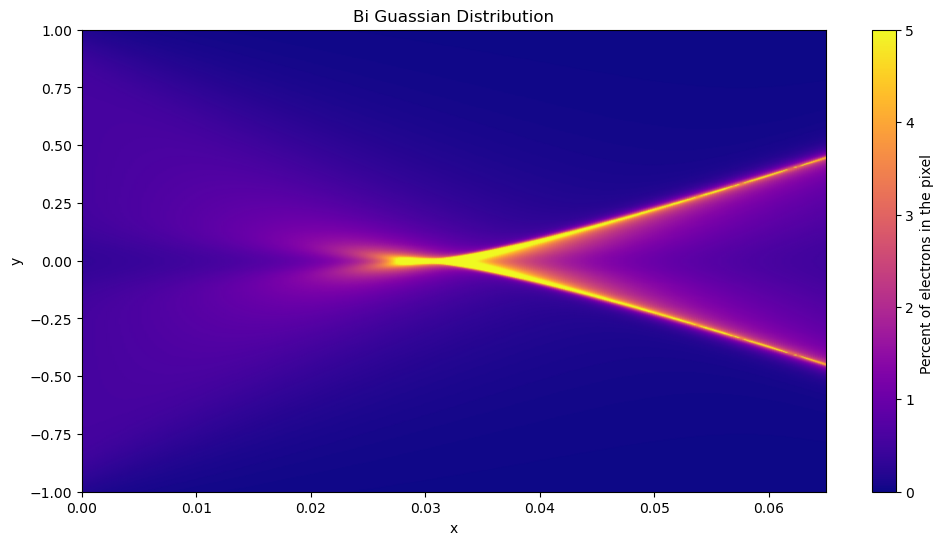

In [1]:
#Bryson Mariano
#6/3/2026
#########################################################################################
#Libraaries
import numpy as np
import math
import matplotlib.pyplot as plt
#from matplotlib.animation import FuncAnimation
#from matplotlib.colors import LogNorm
#from matplotlib.colors import BoundaryNorm

#########################################################################################
#Universal Parameters
me    = 9.1093837 * 10 ** (-31)  #kg
c     = 299792458.0              #m/s
ne    = 1 * 10.0**15 *10**6      #number density
e0    = 8.85418782 * 10**(-12)   #m^-3 kg^-1s^4 A^2
e     = 1.60217663 * 10**(-19)   #coulombs
wp    = ((ne*e**2)/(me*e0)) ** (1/2)

#Define Parameters
gamma = 110                      #Unitless
k     = 0.475 *me*wp**2          #kg/s^2
rb    = 0.65  *c/wp              #c/omega_p   
px    = 110   *me*c              #mec

f0=((px)**2) / (gamma * me * k)
#########################################################################################
#Adjust these parameters 
y0rb= np.linspace(-0.9, 0.9, 100)
dyrb= 0.09

x=np.linspace(0,0.1,500)
y=np.linspace(-1,1,500)
x,y=np.meshgrid(x, y, sparse=False)

y0= y0rb
dy= dyrb
#########################################################################################
#Speacial Functions
def f_cyl(i):
    return ( f0/(2*rb) *1/(np.sqrt(1-(i)**2)))

def f_cylprime(i):
    return ( f0 /(2*rb) * (1-(i)**2)**(-3/2) * (i**2)  )
########################################################################################

fig, ax2= plt.subplots(figsize=(12,6))


Phi_total = np.zeros_like(x)

j=0
for i in range(len(y0)):

    if y0[i] > 0:
        Ymid = (y0[i] + y0[i]+dy)/2
    
        f1 = f_cyl(y0[i])
        f2 = f_cyl(y0[i] + dy)
        f3 = f_cyl(Ymid)
    
        sigma_y = np.abs(dy - ((y0[i] + dy)/f2 - y0[i]/f1)*x )
        mu_y = -(Ymid/f3)*x + Ymid
    else:
        Ymid = (y0[i] + y0[i]-dy)/2
    
        f1 = f_cyl(y0[i])
        f2 = f_cyl(y0[i] - dy)
        f3 = f_cyl(Ymid)
    
        sigma_y = np.abs(-dy - ((y0[i] - dy)/f2 - y0[i]/f1)*x )
        mu_y = -(Ymid/f3)*x + Ymid
    
    Phi_y = ( 1/(sigma_y*np.sqrt(2*np.pi))) * np.exp( -0.5*(y-mu_y)**2/sigma_y**2)

    Phi_total += Phi_y
    j+=1
    
Phi_total=Phi_total/(j)

im = ax2.pcolormesh(x, y, Phi_total, cmap='plasma', shading='gouraud', vmin=0, vmax=5)


fig.colorbar(im, ax=ax2, label='Percent of electrons in the pixel ')


ax2.axvline(x=0, linestyle='--')
#Set Limits and labels on x
ax2.set_xlim(0,0.065)
ax2.set_xlabel("x")

#Set Limits and labels on y
ax2.set_ylim(-1,1)
ax2.set_ylabel("y")

#Show the plot and the specific details of the plot
ax2.set_title("Bi Guassian Distribution")


plt.show()

